In [1]:
import pandas as pd
import numpy as np
import sklearn
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("sklearn:", sklearn.__version__)


pandas: 3.0.5
numpy: 2.5.1
sklearn: 1.9.0


In [2]:
import xgboost
print(xgboost.__version__)

3.4.1


In [3]:
df = pd.read_csv('fraud_oracle.csv')
df.shape

(15420, 33)

In [4]:
import subprocess
import sys

packages = ['pandas', 'numpy', 'scikit-learn', 'xgboost', 'matplotlib', 'seaborn']

for package in packages:
    try:
        __import__(package.replace('-', '_'))
        print(f"{package} already installed")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

pandas already installed
numpy already installed
Installing scikit-learn...
xgboost already installed
matplotlib already installed
seaborn already installed


In [5]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV

df = pd.read_csv('fraud_oracle.csv')
print(df.shape)
print(df['FraudFound_P'].value_counts())

(15420, 33)
FraudFound_P
0    14497
1      923
Name: count, dtype: int64


In [10]:
# data cleaning-------------------------------------------------

In [11]:
df_clean = df.drop(columns=['PolicyNumber'])
df_clean['Age'] = df_clean['Age'].replace(0, df_clean['Age'].median())

categorical_cols = df_clean.select_dtypes(include='object').columns
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
df_encoded = df_encoded.astype(int)   # fixes True/False -> 0/1

print(df_encoded.shape)

(15420, 124)


C:\Users\chait\AppData\Local\Temp\ipykernel_1764\3759403341.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include='object').columns


In [12]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Age=0 issues fixed:", (df['Age'] == 0).sum(), "rows corrected")
print("Before cleaning:", df.shape)
print("After cleaning:", df_encoded.shape)
print(df_encoded.dtypes.value_counts())
df_encoded.head()

Missing values: 0
Duplicate rows: 0
Age=0 issues fixed: 320 rows corrected
Before cleaning: (15420, 33)
After cleaning: (15420, 124)
int64    124
Name: count, dtype: int64


,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,RepNumber,Deductible,DriverRating,Year,Month_Aug,Month_Dec,...,AddressChange_Claim_2 to 3 years,AddressChange_Claim_4 to 8 years,AddressChange_Claim_no change,AddressChange_Claim_under 6 months,NumberOfCars_2 vehicles,NumberOfCars_3 to 4,NumberOfCars_5 to 8,NumberOfCars_more than 8,BasePolicy_Collision,BasePolicy_Liability
0,5,1,21,0,12,300,1,1994,0,1,...,0,0,0,0,0,1,0,0,0,1
1,3,4,34,0,15,400,4,1994,0,0,...,0,0,1,0,0,0,0,0,1,0
2,5,2,47,0,7,400,3,1994,0,0,...,0,0,1,0,0,0,0,0,1,0
3,2,1,65,0,4,400,2,1994,0,0,...,0,0,1,0,0,0,0,0,0,1
4,5,2,27,0,3,400,1,1994,0,0,...,0,0,1,0,0,0,0,0,1,0


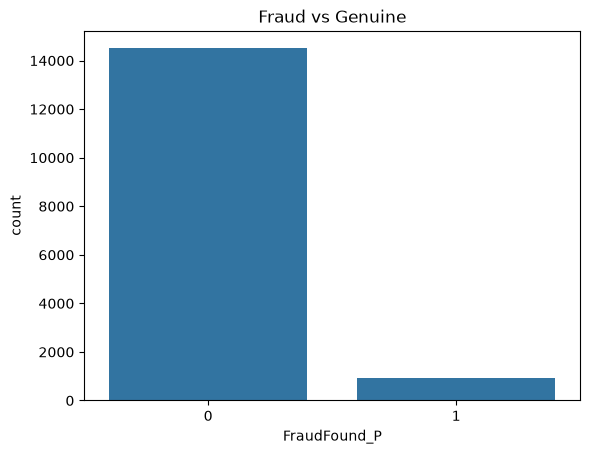

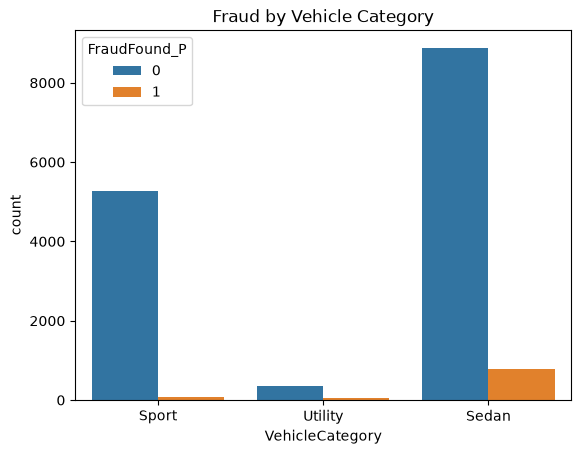

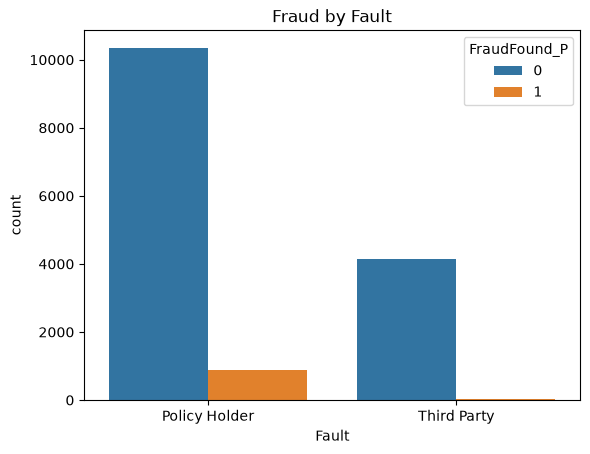

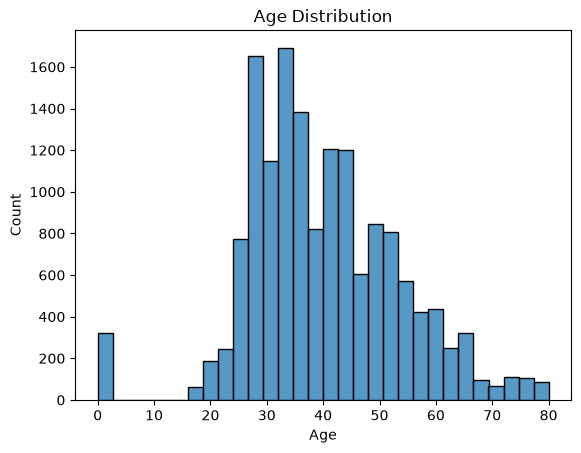

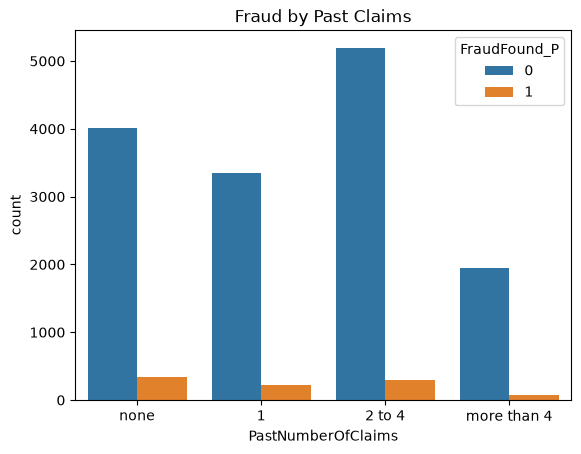

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='FraudFound_P', data=df); plt.title('Fraud vs Genuine'); plt.show()
sns.countplot(x='VehicleCategory', hue='FraudFound_P', data=df); plt.title('Fraud by Vehicle Category'); plt.show()
sns.countplot(x='Fault', hue='FraudFound_P', data=df); plt.title('Fraud by Fault'); plt.show()
sns.histplot(df['Age'], bins=30); plt.title('Age Distribution'); plt.show()